## Phase 8 — Analysis & Interpretability

This section presents a comprehensive analysis of the trained models, focusing on **interpretability, error behaviour, and generalisation performance**. While earlier phases established model performance through quantitative metrics, this phase goes deeper by examining *how* and *why* the models make decisions.

The analysis integrates multiple perspectives:
- **Attention-based interpretability**, using transformer attention weights to identify which tokens influence predictions  
- **Error categorisation**, grouping misclassifications into meaningful linguistic and structural failure modes  
- **Generalisation analysis**, evaluating performance across different corpus sources (DrugBank vs MedLine)  
- **Class-specific investigation**, with particular emphasis on the challenging `int` class  
- **Linguistic feature analysis**, exploring keyword density, sentence structure, and negation patterns  

By combining quantitative metrics with qualitative insights, this section provides a **holistic understanding of model behaviour**, highlighting both strengths and limitations. The outputs generated here also support the final report through visualisations and reproducible metrics.

## Analysis Environment Setup

This section initialises the environment for model analysis and error inspection. It imports the required libraries for data handling, visualisation, model loading, and evaluation, while also configuring reproducibility through fixed random seeds.

The setup supports both classical and transformer-based analysis by loading utilities for sparse features, PyTorch models, and performance metrics. Output directories for plots and metrics are created automatically, ensuring that all analysis artefacts are stored in a consistent location.

The available device is then selected dynamically (`cuda`, `mps`, or `cpu`) so that the notebook can run efficiently across different hardware environments. Finally, common plotting settings and a helper function are defined to standardise figure generation throughout the analysis stage.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../'))
from config import *

import re, json, pickle, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
import torch.nn as nn
from pathlib import Path
from collections import Counter, defaultdict
from scipy import sparse

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import (
    classification_report, f1_score, confusion_matrix,
    balanced_accuracy_score, matthews_corrcoef,
)

warnings.filterwarnings('ignore')
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# Output Directories
try:
    ANALYSIS_PLOTS_DIR   = Path(str(PLOTS_DIR))   / 'analysis'
    ANALYSIS_METRICS_DIR = Path(str(METRICS_DIR)) / 'analysis'
except NameError:
    ANALYSIS_PLOTS_DIR   = Path(str(RESULTS_DIR)) / 'plots'   / 'analysis'
    ANALYSIS_METRICS_DIR = Path(str(RESULTS_DIR)) / 'metrics' / 'analysis'

ANALYSIS_PLOTS_DIR.mkdir(parents=True, exist_ok=True)
ANALYSIS_METRICS_DIR.mkdir(parents=True, exist_ok=True)

# Device
DEVICE = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps' if torch.backends.mps.is_available() else
    'cpu'
)

# Shared Class Names
CLASS_NAMES = [ID2LABEL[i] for i in sorted(ID2LABEL)]

# Plot Style
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.25, 'grid.linestyle': '--',
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'sans-serif', 'font.size': 11,
})

# Save Figure Utility
def save_fig(name):
    path = ANALYSIS_PLOTS_DIR / f'{name}.png'
    plt.savefig(path, dpi=180, bbox_inches='tight', facecolor='white')
    plt.show()

/Users/carinadesouza/Documents/Projects/Python/Drug Drug Interaction NLP project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Best Model Selection for Analysis

This step loads the results of the model comparison phase and identifies the best-performing models across different categories.

The following selections are extracted:
- **Best overall model** — highest-performing model across all approaches
- **Best transformer model** — used for attention and interpretability analysis
- **Best classical model** — baseline comparison reference

The configuration ensures that Phase 8 (analysis) dynamically uses the best transformer model without hardcoding any specific architecture. This improves reproducibility and keeps the pipeline modular.

Model paths and prediction files are resolved using predefined mappings, allowing seamless loading of trained weights and outputs.

If different models need to be analysed, the selection can be updated by re-running the model comparison phase (Phase 7).

In [2]:
best_model_json = Path(str(METRICS_COMPARISON_DIR)) / 'best_model_info.json'

if not best_model_json.exists():
    raise FileNotFoundError(
        f'best_model_info.json not found at {best_model_json}.\n'
        'Run 07_model_comparison.ipynb first to generate it.'
    )

with open(best_model_json) as f:
    best_info = json.load(f)

BEST_MODEL = best_info['best_model']
BEST_TRANSFORMER = best_info['best_transformer']
BEST_CLASSICAL = best_info['best_classical']
TRANS_AVAILABLE  = best_info['trans_available']

TRANSFORMER_PATH_MAP = {
    'BioBERT': BIOBERT_DIR,
    'PubMedBERT': PUBMEDBERT_DIR,
    'SciBERT': SCIBERT_DIR,
}

TRANSFORMER_PRED_MAP = {
    'BioBERT': BIOBERT_PREDS_NPY,
    'PubMedBERT': PUBMEDBERT_PREDS_NPY,
    'SciBERT': SCIBERT_PREDS_NPY,
}

ATTN_MODEL_DIR  = TRANSFORMER_PATH_MAP[BEST_TRANSFORMER]
ATTN_PRED_PATH  = TRANSFORMER_PRED_MAP[BEST_TRANSFORMER]
ATTN_MODEL_NAME = BEST_TRANSFORMER

print(f'Best model overall : {BEST_MODEL}')
print(f'Best transformer : {BEST_TRANSFORMER}  (attention analysis will use this)')
print(f'Best classical : {BEST_CLASSICAL}')
print(f'Transformers present : {TRANS_AVAILABLE}')
print(f'Model weights path : {ATTN_MODEL_DIR}')
print()

Best model overall : SciBERT
Best transformer : SciBERT  (attention analysis will use this)
Best classical : Linear SVM
Transformers present : ['BioBERT', 'PubMedBERT', 'SciBERT']
Model weights path : /Users/carinadesouza/Documents/Projects/Python/Drug Drug Interaction NLP project/models/scibert



## Prediction Loading and Error Segmentation

This step loads the test dataset along with predictions from the best-performing transformer model and prepares the data for detailed error analysis.

The true labels and predicted labels are mapped back to their original class names for interpretability. Each prediction is then evaluated to determine whether it is correct or incorrect.

The dataset is split into:
- **Correct predictions** — instances where the model prediction matches the ground truth  
- **Error cases** — instances where the model prediction is incorrect  

Key evaluation metrics such as accuracy and Macro F1-score are also computed to summarise model performance. Macro F1 is particularly important here due to class imbalance, as it gives equal weight to all interaction types.

This structured separation forms the foundation for deeper analysis in subsequent steps, such as identifying systematic errors, class confusion patterns, and attention behaviour.

In [3]:
print(f'Loading test data and {ATTN_MODEL_NAME} predictions')

test_df = pd.read_csv(TEST_PROCESSED)
y_true  = np.load(Y_TEST_NPY)

print(f'Test rows : {len(test_df):,}')

# Load best-transformer predictions dynamically
y_pred_best_trans = np.load(ATTN_PRED_PATH)

pred_col = ATTN_MODEL_NAME.lower().replace(' ', '_').replace('-', '_') + '_pred'

test_df['true_label']  = [ID2LABEL[i] for i in y_true]
test_df[pred_col] = [ID2LABEL[i] for i in y_pred_best_trans]
test_df['model_correct'] = (test_df['true_label'] == test_df[pred_col])

errors  = test_df[~test_df['model_correct']].copy()
correct = test_df[test_df['model_correct']].copy()

macro_f1 = f1_score(y_true, y_pred_best_trans, average='macro', zero_division=0)

print(f'\n{ATTN_MODEL_NAME} accuracy : {test_df["model_correct"].mean()*100:.1f}%')
print(f'Correct : {len(correct):,}')
print(f'Errors : {len(errors):,}  ({len(errors)/len(test_df)*100:.1f}%)')
print(f'Macro F1 : {macro_f1:.4f}')

Loading test data and SciBERT predictions
Test rows : 6,657

SciBERT accuracy : 91.8%
Correct : 6,109
Errors : 548  (8.2%)
Macro F1 : 0.7307


## Transformer Loading for Attention Analysis

This step loads the fine-tuned best transformer model and its tokenizer for interpretability analysis. The model is configured to return attention weights, which are required for examining which tokens receive the strongest focus during prediction.

The tokenizer is loaded from the same directory as the trained model to ensure consistency with the original training setup. The model is then initialised with label mappings and moved to the available device for efficient inference.

Additional model properties such as the total number of parameters, attention layers, and attention heads are displayed to summarise the architecture being analysed. This confirms that the model is correctly configured and ready for extracting attention-based explanations.

In [4]:
print(f'Loading fine-tuned {ATTN_MODEL_NAME} for attention extraction')

ATTN_TOKENISER = AutoTokenizer.from_pretrained(ATTN_MODEL_DIR)

ATTN_MODEL = AutoModelForSequenceClassification.from_pretrained(
    ATTN_MODEL_DIR,
    output_attentions=True,
    attn_implementation='eager',
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)

ATTN_MODEL.eval()
ATTN_MODEL = ATTN_MODEL.to(DEVICE)

n_params = sum(p.numel() for p in ATTN_MODEL.parameters())
n_layers = ATTN_MODEL.config.num_hidden_layers
n_heads  = ATTN_MODEL.config.num_attention_heads

print(f'Parameters : {n_params/1e6:.1f}M')
print(f'Attention layers : {n_layers}')
print(f'Attention heads/layer: {n_heads}')

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Loading fine-tuned SciBERT for attention extraction
Parameters : 109.9M
Attention layers : 12
Attention heads/layer: 12


## CLS Attention Extraction

This section defines a utility function to extract attention weights from the fine-tuned transformer model for interpretability analysis. The function focuses on the attention distribution from the **[CLS] token**, which is commonly used by transformer classifiers as the aggregate representation for sentence-level prediction.

Two modes are supported: using only the **last attention layer** or averaging attention across **all layers**. The last-layer view provides a simple baseline, while the mean-layer view offers a more stable and robust interpretation by reducing layer-specific noise.

For a given input sentence, the function returns the tokenised sequence, the normalised attention weights for each token, and the predicted class label. This makes it possible to inspect which words or subwords contribute most strongly to the model’s decision.

A small smoke test is included to verify that attention extraction is working correctly and that the model assigns sensible attention to important terms such as `contraindicated`, `DRUG1`, and `DRUG2`.

In [5]:
def extract_cls_attention(
    text: str,
    model,
    tokeniser,
    max_len: int = 128,
    layer: str = 'last',
):
    """
    Extract CLS-token attention weights from a fine-tuned transformer.
    """
    enc = tokeniser(
        text,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_tensors='pt',
    )

    input_ids = enc['input_ids'].to(DEVICE)
    attention_mask = enc['attention_mask'].to(DEVICE)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

    all_attentions = outputs.attentions

    if layer == 'last':
        cls_attn = all_attentions[-1][0, :, 0, :]
    elif layer == 'mean':
        stacked = torch.stack([a[0, :, 0, :] for a in all_attentions])
        cls_attn = stacked.mean(dim=0)
    else:
        raise ValueError(f'layer must be "last" or "mean", got: {layer!r}')

    cls_attn_mean = cls_attn.mean(dim=0).cpu().numpy()

    seq_len = int(attention_mask.sum().item())
    tokens = tokeniser.convert_ids_to_tokens(input_ids[0, :seq_len].cpu().numpy())
    weights = cls_attn_mean[:seq_len]
    weights = weights / weights.sum()

    pred_label = ID2LABEL[int(np.argmax(outputs.logits[0].cpu().numpy()))]
    return tokens, weights, pred_label


# Quick smoke test
sample_text = 'DRUG1 is contraindicated in patients receiving DRUG2 therapy.'
toks, wts, pred = extract_cls_attention(
    sample_text,
    ATTN_MODEL,
    ATTN_TOKENISER,
    layer='last'
)

print(f'Sample sentence : "{sample_text}"')
print(f'Predicted class : {pred}')
print(f'Top-5 attended tokens (last layer):')

for idx in np.argsort(wts)[-5:][::-1]:
    print(f'[{idx:3d}] {toks[idx]:<20} {wts[idx]:.4f}')

Sample sentence : "DRUG1 is contraindicated in patients receiving DRUG2 therapy."
Predicted class : advise
Top-5 attended tokens (last layer):
[ 11] [SEP]                0.1820
[ 10] .                    0.1742
[  1] DRUG1                0.1707
[  0] [CLS]                0.1031
[  2] is                   0.0639


## Selection of Representative Sentences for Attention Analysis

This step selects a small set of representative sentences from the correctly predicted test samples for each interaction class.

For each class, up to two sentences are randomly sampled, prioritising those with moderate length (10–30 words). This constraint avoids extremely short or long sentences, ensuring that attention visualisations remain interpretable and meaningful.

Only correctly classified examples are used so that the attention patterns reflect **valid model reasoning**, rather than noise from misclassifications.

The selected sentences are stored in a structured dictionary, enabling consistent downstream visualisation and comparison across interaction types.

In [6]:
random.seed(RANDOM_STATE)

SELECTED = {}

for label in LABEL_ORDER:
    pool = (
        test_df[
            (test_df['true_label'] == label) &
            (test_df['model_correct'] == True)
        ]['sentence_masked']
        .dropna()
        .tolist()
    )

    pool_short = [s for s in pool if 10 <= len(s.split()) <= 30]
    candidates = pool_short if len(pool_short) >= 2 else pool

    n_pick = min(2, len(candidates))
    picked = random.sample(candidates, n_pick)

    SELECTED[label] = picked

    print(f'{label:<12}: {len(pool):4d} correct predictions  | picked {n_pick}')
    for i, s in enumerate(picked):
        print(f'  [{i+1}] {s[:90]}{"..." if len(s) > 90 else ""}')
    print()

total_selected = sum(len(v) for v in SELECTED.values())

print(f'Total sentences selected for attention visualisation: {total_selected}')

false       : 5363 correct predictions  | picked 2
  [1] No significant adverse interactions with common premedications (such as atropine, DRUG1, g...
  [2] While there is evidence that fluconazole can inhibit the metabolism of DRUG2 and DRUG1, th...

effect      :  290 correct predictions  | picked 2
  [1] DRUG1 users who initiated citalopram, fluoxetine, DRUG2, amitriptyline, or mirtazapine had...
  [2] If a DRUG1 is also used, the risk of DRUG2 toxicity may be increased. 

mechanism   :  232 correct predictions  | picked 2
  [1] John   s Wort, and certain anticonvulsants (phenytoin, DRUG1, carbamazepine) may induce DR...
  [2] Inducers of CYP3A4 Isozymes: Cytochrome P450 inducers, such as DRUG1, carbamazepine, and p...

advise      :  189 correct predictions  | picked 2
  [1] Coadministration of DRUG1 with ferrous sulfate or DRUG2 is not recommended. 
  [2] Nevertheless, during concomitant therapy with DRUG1 and DRUG2, patients should be observed...

int         :   35 correct predi

## Attention-Based Token Importance (Class-Level)

This step aggregates attention scores across selected correctly predicted sentences to identify the most influential tokens for each interaction class.

For each class:
- Attention weights from the CLS token are extracted
- Subword tokens are cleaned and filtered (removing special tokens and drug placeholders)
- Attention scores are accumulated and normalised across sentences

The result is a ranked list of the **top 10 most-attended tokens per class**, providing insight into what linguistic signals the model relies on for its predictions.

This analysis serves as a **global interpretability view**, complementing earlier instance-level attention inspection. It helps verify whether the model is focusing on clinically meaningful terms, such as:
- *mechanism*: enzyme, inhibit, metabolism  
- *advise*: contraindicated, monitor, caution  
- *interaction*: interact, combination  
- *false*: negation terms like not, no, without  

The output is also saved as a CSV file for reporting and further analysis.

In [7]:
EXCLUDE_TOKENS = {'[cls]', '[sep]', '[pad]', '', 'drug1', 'drug2'}

class_top_tokens = defaultdict(list)

for label in LABEL_ORDER:
    for sent in SELECTED.get(label, []):
        toks, wts, pred = extract_cls_attention(
            sent,
            ATTN_MODEL,
            ATTN_TOKENISER,
            layer='last'
        )

        for tok, w in zip(toks, wts):
            clean = tok.replace('##', '').lower().strip()

            if clean not in EXCLUDE_TOKENS and len(clean) > 2:
                class_top_tokens[label].append((clean, w))

summary_rows = []

for label in LABEL_ORDER:
    tok_agg = defaultdict(float)

    for tok, w in class_top_tokens[label]:
        tok_agg[tok] += w

    total_w = sum(tok_agg.values())

    if total_w > 0:
        tok_agg = {t: v / total_w for t, v in tok_agg.items()}

    top10 = sorted(tok_agg.items(), key=lambda x: -x[1])[:10]

    for rank, (tok, w) in enumerate(top10, 1):
        summary_rows.append({
            'Class': label,
            'Rank': rank,
            'Token': tok,
            'Relative Attention': round(w, 5)
        })

summary_df = pd.DataFrame(summary_rows)

pivot_summary = summary_df.pivot_table(
    index='Rank',
    columns='Class',
    values='Token',
    aggfunc='first'
)[LABEL_ORDER]

print('-' * 70)
print(f'  Top 10 Most-Attended Tokens per Class ({ATTN_MODEL_NAME}, last layer)')
print('-' * 70)
print(pivot_summary.to_string())

print()
print('Key expected patterns:')
print('mechanism: CYP/inhibit/metabol/enzyme/clearance tokens')
print('advise: contraindicated/monitor/caution/avoid tokens')
print('int: interact/combination/co-admin tokens')
print('false: not/no/without (negation) prominently')

summary_df.to_csv(
    ANALYSIS_METRICS_DIR / 'attention_top_tokens_per_class.csv',
    index=False
)

----------------------------------------------------------------------
  Top 10 Most-Attended Tokens per Class (SciBERT, last layer)
----------------------------------------------------------------------
Class       false           effect   mechanism          advise       int
Rank                                                                    
1             con             used  metabolism             fer  interact
2           azole         toxicity       adult             and       can
3             flu             risk      induce    nevertheless       may
4          induce         bleeding         may             not      with
5             net  hospitalization        oral            with   adrenal
6             and              the         auc         therapy  decrease
7        evidence        increased         450     recommended   causing
8      metabolism              may         and          during  function
9            glyc        initiated      caused     concomitant    

## Domain-Specific Attention Analysis

This analysis quantifies how much of the model’s attention is focused on **domain-relevant pharmacological terms** for each interaction class.

A predefined set of domain tokens is used for each class (e.g., *inhibit*, *metabol*, *CYP* for mechanism; *contraindicated*, *monitor* for advise). The total attention assigned to these tokens is computed as a percentage of the overall CLS attention.

This provides a **quantitative interpretability metric**, answering:
> *Is the model actually focusing on meaningful biomedical signals?*

Higher percentages indicate that the model relies more on domain-relevant language when making predictions, which strengthens confidence in its reasoning.

The results are visualised as a bar chart and saved for reporting. Ideally:
- **Mechanism / advise / effect classes** → high domain attention  
- **False class** → higher attention on negation terms  

This validates whether the model aligns with expected linguistic patterns in drug–drug interaction detection.

false       : 2.5% attention on domain tokens
effect      : 7.8% attention on domain tokens
mechanism   : 10.0% attention on domain tokens
advise      : 2.2% attention on domain tokens
int         : 11.7% attention on domain tokens


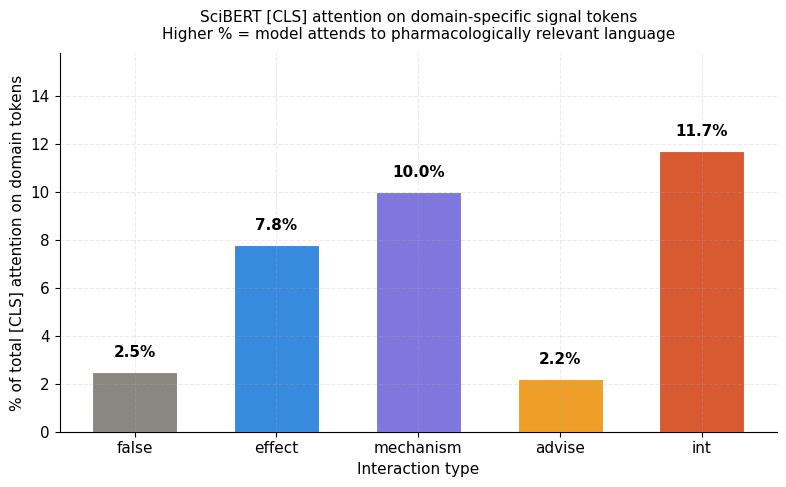

In [8]:
DOMAIN_TOKENS = {
    'mechanism': {'inhibit', 'induc', 'metabol', 'cyp', 'clearance', 'enzyme', 'absorpt', 'half'},
    'effect': {'bleeding', 'toxic', 'adverse', 'risk', 'prolonged', 'sedation', 'elevated'},
    'advise': {'contraindicated', 'avoid', 'caution', 'monitor', 'warning', 'recommend', 'concomitant'},
    'int': {'interact', 'interaction', 'combination', 'co-admin', 'combined'},
    'false': {'not', 'no', 'without', 'neither', 'nor', 'never', 'none'},
}

domain_pct_data = []

for label in LABEL_ORDER:
    all_domain_w = 0.0
    all_total_w = 0.0

    for sent in SELECTED.get(label, []):
        toks, wts, pred = extract_cls_attention(
            sent,
            ATTN_MODEL,
            ATTN_TOKENISER,
            layer='last'
        )

        for tok, w in zip(toks, wts):
            clean = tok.replace('##', '').lower().strip()

            all_total_w += w

            if any(d in clean for d in DOMAIN_TOKENS.get(label, set())):
                all_domain_w += w

    pct = (all_domain_w / all_total_w * 100) if all_total_w > 0 else 0

    domain_pct_data.append({
        'Class': label,
        'Domain token attention %': round(pct, 1)
    })

    print(f'{label:<12}: {pct:.1f}% attention on domain tokens')

domain_df = pd.DataFrame(domain_pct_data)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    domain_df['Class'],
    domain_df['Domain token attention %'],
    color=[LABEL_COLOURS[l] for l in LABEL_ORDER],
    edgecolor='white',
    width=0.6,
    linewidth=0.8
)

for bar, row in zip(bars, domain_df.itertuples()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{row._2:.1f}%',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

ax.set_title(
    f'{ATTN_MODEL_NAME} [CLS] attention on domain-specific signal tokens\n'
    'Higher % = model attends to pharmacologically relevant language',
    fontsize=11,
    pad=10
)

ax.set_xlabel('Interaction type')
ax.set_ylabel('% of total [CLS] attention on domain tokens')

ax.set_ylim(0, max(domain_df['Domain token attention %']) * 1.35)

plt.tight_layout()
save_fig('domain_token_attention_pct')

domain_df.to_csv(
    ANALYSIS_METRICS_DIR / 'domain_token_attention_pct.csv',
    index=False
)

## Error Categorisation Analysis

This step classifies mispredicted samples into structured error categories to better understand model weaknesses.

Each error is assigned to a category based on linguistic patterns, label confusion, or data characteristics. The categories are evaluated in priority order, ensuring that each error is assigned to the most informative explanation.

Key categories include:
- **NEG — Negation reversal**: model fails to interpret negation correctly  
- **LRD — Long-range dependency**: drugs are far apart, making relationships harder to capture  
- **GEN — Generic interaction language**: vague interaction statements misclassified as specific types  
- **AMB2 — Mechanism/effect ambiguity**: confusion between closely related classes  
- **AMB — Ambiguous drug class**: entity types like “group” introduce uncertainty  
- **NOI — Corpus noise**: false samples incorrectly predicted as interactions  
- **DNG — Dangerous miss**: critical interactions predicted as false (most severe error)  
- **OTH — Other**: uncategorised cases  

This structured breakdown provides a **diagnostic view of model behaviour**, helping identify systematic failure modes and guiding improvements in feature design or model architecture.

The results are summarised as counts and percentages, and saved for reporting.

In [9]:
NEGATION_WORDS = {'not', 'no', 'without', 'neither', 'nor', 'never', 'none'}

def categorise_error(row) -> str:
    true = row['true_label']
    pred = row[pred_col]
    cleaned = str(row.get('sentence_cleaned', '')).lower()
    words = set(cleaned.split())

    if bool(words & NEGATION_WORDS) and pred != 'false' and true == 'false':
        return 'NEG — Negation reversal'

    wb = row.get('words_between', -1)
    if isinstance(wb, (int, float)) and wb > 15:
        return 'LRD — Long-range dependency'

    if true == 'int' and pred in {'effect', 'mechanism', 'advise'}:
        return 'GEN — Generic interaction language'

    if (true == 'mechanism' and pred == 'effect') or (true == 'effect' and pred == 'mechanism'):
        return 'AMB2 — Mechanism/effect ambiguity'

    d1_type = str(row.get('drug1_type', '')).lower()
    d2_type = str(row.get('drug2_type', '')).lower()
    if 'group' in d1_type or 'group' in d2_type:
        return 'AMB — Ambiguous drug class'

    if true == 'false' and pred in {'effect', 'mechanism', 'advise', 'int'}:
        return 'NOI — Corpus noise (false → interaction)'

    if true in {'effect', 'mechanism', 'advise', 'int'} and pred == 'false':
        return 'DNG — Dangerous miss (interaction → false)'

    return 'OTH — Other'


errors['error_category'] = errors.apply(categorise_error, axis=1)

cat_counts = errors['error_category'].value_counts()
cat_pct = (cat_counts / len(errors) * 100).round(1)

print('-' * 65)
print(f'  {ATTN_MODEL_NAME} Error Categorisation  (n={len(errors):,} errors)')
print('-' * 65)

cat_df = pd.DataFrame({
    'Count': cat_counts,
    'Pct %': cat_pct
})

print(cat_df.to_string())

print(f'\nTotal categorised: {len(errors):,}')

cat_df.to_csv(ANALYSIS_METRICS_DIR / 'error_categories.csv')

-----------------------------------------------------------------
  SciBERT Error Categorisation  (n=548 errors)
-----------------------------------------------------------------
                                            Count  Pct %
error_category                                          
AMB — Ambiguous drug class                    186   33.9
NOI — Corpus noise (false → interaction)      159   29.0
DNG — Dangerous miss (interaction → false)    115   21.0
GEN — Generic interaction language             40    7.3
NEG — Negation reversal                        28    5.1
AMB2 — Mechanism/effect ambiguity              11    2.0
OTH — Other                                     9    1.6

Total categorised: 548


## Error Category Visualisation

This visualisation provides a comprehensive view of model failure modes using two complementary plots.

### 1. Overall Error Distribution  
The horizontal bar chart shows the total number and percentage of errors for each category. This highlights the most common failure types, allowing quick identification of dominant weaknesses such as negation handling or class ambiguity.

### 2. Error Breakdown by True Class  
The stacked bar chart shows how different error types are distributed within each true interaction class. Each bar represents a class, with segments indicating the proportion of errors belonging to each category.

This helps answer:
- *Which classes are most affected by specific error types?*
- *Are certain failure modes class-specific or general?*

Custom colours and shortened labels improve readability, especially for reporting purposes.

Together, these plots provide both a **global error overview** and a **class-specific diagnostic breakdown**, supporting targeted model improvements.

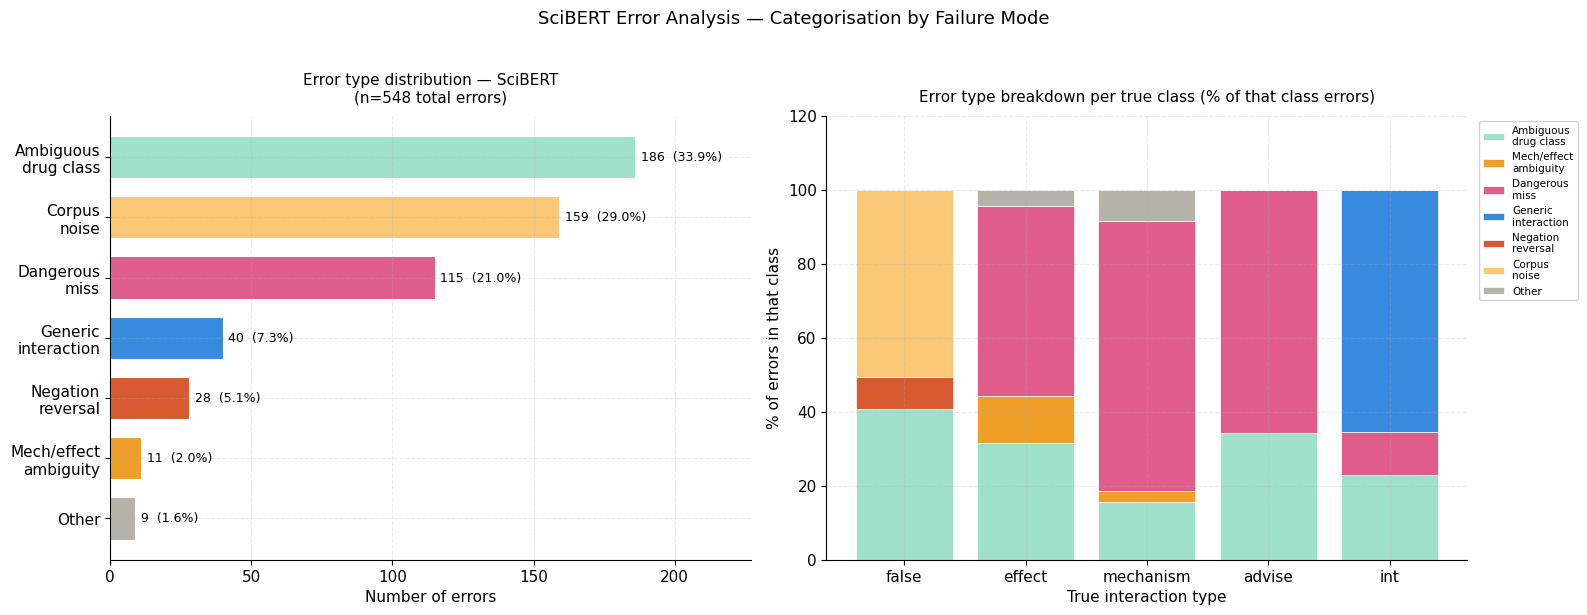

In [10]:
SHORT_LABELS = {
    'NEG — Negation reversal':               'Negation\nreversal',
    'LRD — Long-range dependency':           'Long-range\ndependency',
    'GEN — Generic interaction language':    'Generic\ninteraction',
    'AMB2 — Mechanism/effect ambiguity':     'Mech/effect\nambiguity',
    'AMB — Ambiguous drug class':            'Ambiguous\ndrug class',
    'NOI — Corpus noise (false → interaction)': 'Corpus\nnoise',
    'DNG — Dangerous miss (interaction → false)': 'Dangerous\nmiss',
    'OTH — Other':                           'Other',
}

cat_colours = {
    'NEG — Negation reversal':               '#D85A30',
    'LRD — Long-range dependency':           '#7F77DD',
    'GEN — Generic interaction language':    '#378ADD',
    'AMB2 — Mechanism/effect ambiguity':     '#EF9F27',
    'AMB — Ambiguous drug class':            '#9FE1CB',
    'NOI — Corpus noise (false → interaction)': '#FAC775',
    'DNG — Dangerous miss (interaction → false)': '#E05C8A',
    'OTH — Other':                           '#B4B2A9',
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cats_ordered = cat_counts.index.tolist()
short_cats   = [SHORT_LABELS.get(c, c) for c in cats_ordered]
colours_bar  = [cat_colours.get(c, '#888') for c in cats_ordered]

bars = axes[0].barh(
    short_cats[::-1],
    cat_counts.values[::-1],
    color=colours_bar[::-1],
    edgecolor='white',
    linewidth=0.8,
    height=0.7
)

for bar, val, pct in zip(bars, cat_counts.values[::-1], cat_pct.values[::-1]):
    axes[0].text(
        bar.get_width() + 2,
        bar.get_y() + bar.get_height() / 2,
        f'{val}  ({pct:.1f}%)',
        va='center',
        fontsize=9
    )

axes[0].set_title(
    f'Error type distribution — {ATTN_MODEL_NAME}\n(n={len(errors):,} total errors)',
    fontsize=11,
    pad=10
)

axes[0].set_xlabel('Number of errors')
axes[0].margins(x=0.22)

class_cat_pivot = pd.crosstab(errors['true_label'], errors['error_category'])
class_cat_pivot = class_cat_pivot.reindex(
    [l for l in LABEL_ORDER if l in class_cat_pivot.index]
)

class_cat_pct = class_cat_pivot.div(class_cat_pivot.sum(axis=1), axis=0) * 100

bottom = np.zeros(len(class_cat_pct))

for col in class_cat_pct.columns:
    vals   = class_cat_pct[col].fillna(0).values
    colour = cat_colours.get(col, '#888')

    axes[1].bar(
        class_cat_pct.index,
        vals,
        bottom=bottom,
        label=SHORT_LABELS.get(col, col),
        color=colour,
        edgecolor='white',
        linewidth=0.5
    )

    bottom += vals

axes[1].set_title(
    'Error type breakdown per true class (% of that class errors)',
    fontsize=11,
    pad=10
)

axes[1].set_xlabel('True interaction type')
axes[1].set_ylabel('% of errors in that class')
axes[1].set_ylim(0, 120)

axes[1].legend(
    fontsize=7.5,
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    framealpha=0.9
)

plt.suptitle(
    f'{ATTN_MODEL_NAME} Error Analysis — Categorisation by Failure Mode',
    fontsize=13,
    y=1.02
)

plt.tight_layout()
save_fig('error_categories')

## Qualitative Error Inspection

This step presents representative examples for each error category to support qualitative analysis.

For each category, one or two misclassified sentences are displayed along with:
- The **true label** and **predicted label**
- The **original sentence** (or masked version if unavailable)
- Additional contextual signals depending on the error type:
  - **Negation errors** → detected negation words  
  - **Long-range dependency errors** → distance between drug mentions  
  - **Ambiguous drug class errors** → entity types of drugs  

This complements the quantitative error analysis by providing concrete evidence of failure modes. It helps verify whether the categorisation logic is meaningful and reveals patterns that may not be captured numerically.

These examples are particularly useful for:
- Debugging model behaviour  
- Identifying annotation inconsistencies  
- Motivating improvements in feature engineering or model design  

In [11]:
print('-' * 70)
print(f'  Error Examples per Category — {ATTN_MODEL_NAME} (1–2 per type)')
print('-' * 70)

for cat in cat_counts.index:
    subset = errors[errors['error_category'] == cat]

    print(f'\n{cat}  (n={len(subset):,})')
    print('-' * 60)

    for _, row in subset.head(2).iterrows():
        orig  = str(row.get('sentence_original', row.get('sentence_masked', '')))
        clean = str(row.get('sentence_cleaned', ''))

        print(f'  True: {row["true_label"]:<12}  Pred: {row[pred_col]:<12}')
        print(f'  Sentence : {orig[:120]}')

        if 'NEG' in cat:
            neg_found = [w for w in NEGATION_WORDS if w in clean.split()]
            print(f'  Negation words found: {neg_found}')

        elif 'LRD' in cat:
            print(f'  Words between drugs: {row.get("words_between", "?")}')

        elif 'AMB' in cat and 'AMB2' not in cat:
            print(f'  Drug types: {row.get("drug1_type","?")} + {row.get("drug2_type","?")}')

        print()

----------------------------------------------------------------------
  Error Examples per Category — SciBERT (1–2 per type)
----------------------------------------------------------------------

AMB — Ambiguous drug class  (n=186)
------------------------------------------------------------
  True: false         Pred: mechanism   
  Sentence : Multiple dose studies of ezetimibe given in combination with HMG-CoA reductase inhibitors (statins) in rats and rabbits 
  Drug types: drug + group

  True: false         Pred: mechanism   
  Sentence : Multiple dose studies of ezetimibe given in combination with HMG-CoA reductase inhibitors (statins) in rats and rabbits 
  Drug types: drug + group


NOI — Corpus noise (false → interaction)  (n=159)
------------------------------------------------------------
  True: false         Pred: mechanism   
  Sentence : In a study of 11 HIV-infected patients receiving methadone-maintenance therapy (40 mg and 90 mg daily) with 600 mg of ZI

  True: fal

## Multi-Model Prediction Loading (Generalisation Analysis)

This step loads predictions from all available models to enable comparative generalisation analysis.

The following model families are included:
- **Classical ML models**: Naive Bayes, Logistic Regression, Random Forest, Linear SVM  
- **Rule-based baseline**: keyword-driven heuristic predictions  
- **Transformer models**: BioBERT, PubMedBERT, SciBERT (if available)  

Each model generates predictions on the same test set, allowing direct comparison of their behaviour on identical inputs.

Special handling is applied for Naive Bayes to ensure compatibility with feature constraints (non-negative inputs). The rule-based model provides a simple baseline grounded in domain keywords, useful for benchmarking learned models.

All predictions are stored in a unified dictionary, forming the basis for downstream analysis such as:
- Agreement/disagreement between models  
- Robustness across model types  
- Identification of consistently difficult samples  

This step ensures a **holistic evaluation across modelling paradigms**, rather than relying on a single best model.

In [12]:
print('Loading all model predictions for generalisation analysis')

X_test = sparse.load_npz(TEST_FEATURES_NPZ)

with open(LABEL_ENCODER_PKL, 'rb') as f:
    encoder = pickle.load(f)

all_preds = {}

for fname, name in [
    ('naive_bayes.pkl', 'Naive Bayes'),
    ('logistic_regression.pkl', 'Logistic Regression'),
    ('random_forest.pkl', 'Random Forest'),
    ('svm.pkl', 'Linear SVM'),
]:
    fpath = os.path.join(str(FEATURES_ARTEFACTS_DIR), fname)

    if os.path.exists(fpath):
        with open(fpath, 'rb') as f:
            m = pickle.load(f)

        if 'naive' in fname:
            X_nb = np.clip(X_test.toarray().astype(np.float32), 0, None)
            wb_idx = X_test.shape[1] - 24 + 3
            X_nb[:, wb_idx] = np.clip(X_nb[:, wb_idx], 0, None)
            all_preds[name] = m.predict(X_nb)
        else:
            all_preds[name] = m.predict(X_test)

        print(f'{name:<22} loaded')
    else:
        print(f'{name:<22} MISSING — skipped')

# Rule-based baseline
RULES = {
    'mechanism': {'inhibit','induce','metabolis','metaboliz','cyp','enzyme',
                  'absorption','clearance','half-life','bioavailability','pharmacokinetic'},
    'effect': {'bleeding','toxicity','sedation','hypotension','bradycardia',
                  'adverse','side effect','prolonged','elevated'},
    'advise': {'contraindicated','avoid','caution','recommend','monitor',
                  'warning','should not','do not','concomitant'},
    'int': {'interact','interaction','combined with','co-administration','combination'},
}

def rule_predict(sentences):
    preds = []
    for s in sentences:
        sl = str(s).lower()
        pred = 'false'

        for lbl in ['mechanism', 'effect', 'advise', 'int']:
            if any(kw in sl for kw in RULES[lbl]):
                pred = lbl
                break

        preds.append(pred)

    return preds

all_preds['Rule-based'] = encoder.transform(
    rule_predict(test_df['sentence_cleaned'])
)

# Transformer predictions
for trans_name, pred_path in [
    ('BioBERT', BIOBERT_PREDS_NPY),
    ('PubMedBERT', PUBMEDBERT_PREDS_NPY),
    ('SciBERT', SCIBERT_PREDS_NPY),
]:
    if trans_name in TRANS_AVAILABLE and os.path.exists(pred_path):
        all_preds[trans_name] = np.load(pred_path)
        print(f'  {trans_name:<22} loaded')

Loading all model predictions for generalisation analysis
Naive Bayes            loaded
Logistic Regression    loaded
Random Forest          loaded
Linear SVM             loaded
  BioBERT                loaded
  PubMedBERT             loaded
  SciBERT                loaded


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


## Generalisation Analysis Across Data Sources

This analysis evaluates how well different models generalise across two distinct corpora: **DrugBank** and **MedLine**.

Each model’s performance is computed separately on these subsets using **Macro F1-score**, ensuring fair comparison across imbalanced classes. In addition, class-wise F1 scores are recorded to identify which interaction types are most affected by domain shift.

The analysis includes:
- **Rule-based baseline**
- **Best classical model**
- **All available transformer models**

Key insights derived from this step:
- Whether transformer models generalise better than classical models  
- Performance gaps between structured (DrugBank) and unstructured (MedLine) data  
- Relative improvement over rule-based approaches  

Performance differences (Δ Macro F1) are explicitly calculated to highlight gains or degradation across models and sources.

This provides a critical evaluation of **model robustness and domain transferability**, which is essential for real-world deployment.

In [13]:
# Use BEST_CLASSICAL + BEST_TRANSFORMER dynamically; BioBERT included if available
MODELS_FOR_ANALYSIS = [
    m for m in ['Rule-based', BEST_CLASSICAL] + TRANS_AVAILABLE
    if m in all_preds
]

source_results = []

for source in ['DrugBank', 'MedLine']:
    mask = test_df['corpus_source'].str.strip() == source
    source_idx = np.where(mask.values)[0]

    y_true_source = y_true[source_idx]
    n_rows = len(source_idx)

    for model_name in MODELS_FOR_ANALYSIS:
        if model_name not in all_preds:
            continue

        preds_source = all_preds[model_name][source_idx]

        macro_f1 = f1_score(
            y_true_source,
            preds_source,
            average='macro',
            zero_division=0
        )

        rep = classification_report(
            y_true_source,
            preds_source,
            target_names=CLASS_NAMES,
            output_dict=True,
            zero_division=0
        )

        row = {
            'Model': model_name,
            'Source': source,
            'N': n_rows,
            'Macro F1': round(macro_f1, 4)
        }

        for lbl in LABEL_ORDER:
            if lbl in rep:
                row[f'F1({lbl})'] = round(rep[lbl]['f1-score'], 4)

        source_results.append(row)

source_df = pd.DataFrame(source_results)

pivot = source_df.pivot_table(
    index='Model',
    columns='Source',
    values='Macro F1'
)

print('-' * 60)
print('  Macro F1 by Corpus Source')
print('-' * 60)

print(pivot.reindex(MODELS_FOR_ANALYSIS).round(4).to_string())
print()

for source in ['DrugBank', 'MedLine']:
    sub = source_df[source_df['Source'] == source].set_index('Model')

    if BEST_TRANSFORMER in sub.index and BEST_CLASSICAL in sub.index:
        delta = sub.loc[BEST_TRANSFORMER, 'Macro F1'] - sub.loc[BEST_CLASSICAL, 'Macro F1']
        print(f'{source}: {BEST_TRANSFORMER} vs {BEST_CLASSICAL}  Δ Macro F1 = {delta:+.4f}')

    if 'Rule-based' in sub.index and BEST_TRANSFORMER in sub.index:
        delta_rb = sub.loc[BEST_TRANSFORMER, 'Macro F1'] - sub.loc['Rule-based', 'Macro F1']
        print(f'{source}: {BEST_TRANSFORMER} vs Rule-based    Δ Macro F1 = {delta_rb:+.4f}')

    print()

source_df.to_csv(
    ANALYSIS_METRICS_DIR / 'generalisation_by_source.csv',
    index=False
)

------------------------------------------------------------
  Macro F1 by Corpus Source
------------------------------------------------------------
Source      DrugBank  MedLine
Model                        
Rule-based    0.1896   0.2149
Linear SVM    0.5497   0.4627
BioBERT       0.6931   0.4992
PubMedBERT    0.7425   0.5056
SciBERT       0.7430   0.5237

DrugBank: SciBERT vs Linear SVM  Δ Macro F1 = +0.1933
DrugBank: SciBERT vs Rule-based    Δ Macro F1 = +0.5534

MedLine: SciBERT vs Linear SVM  Δ Macro F1 = +0.0610
MedLine: SciBERT vs Rule-based    Δ Macro F1 = +0.3088



## Generalisation Visualisation (DrugBank vs MedLine)

This visualisation compares model performance across two different data sources to assess robustness and domain generalisation.

### 1. Macro F1 Comparison  
The grouped bar chart shows Macro F1 scores for each model on:
- **DrugBank** (structured, cleaner data)  
- **MedLine** (unstructured, noisier clinical text)  

This highlights how performance varies across domains and whether models trained on one distribution generalise well to another.

### 2. Transformer Gain over Classical Baseline  
The delta plot measures the improvement (Δ Macro F1) of transformer models relative to the best classical model. This provides a clear view of:
- Whether transformers consistently outperform classical approaches  
- How much improvement is retained across different data sources  

A horizontal zero line indicates parity with the classical model. Positive values indicate improvement, while negative values indicate degradation.

Together, these plots provide a **comparative and diagnostic view of cross-domain performance**, helping identify models that are both accurate and robust.

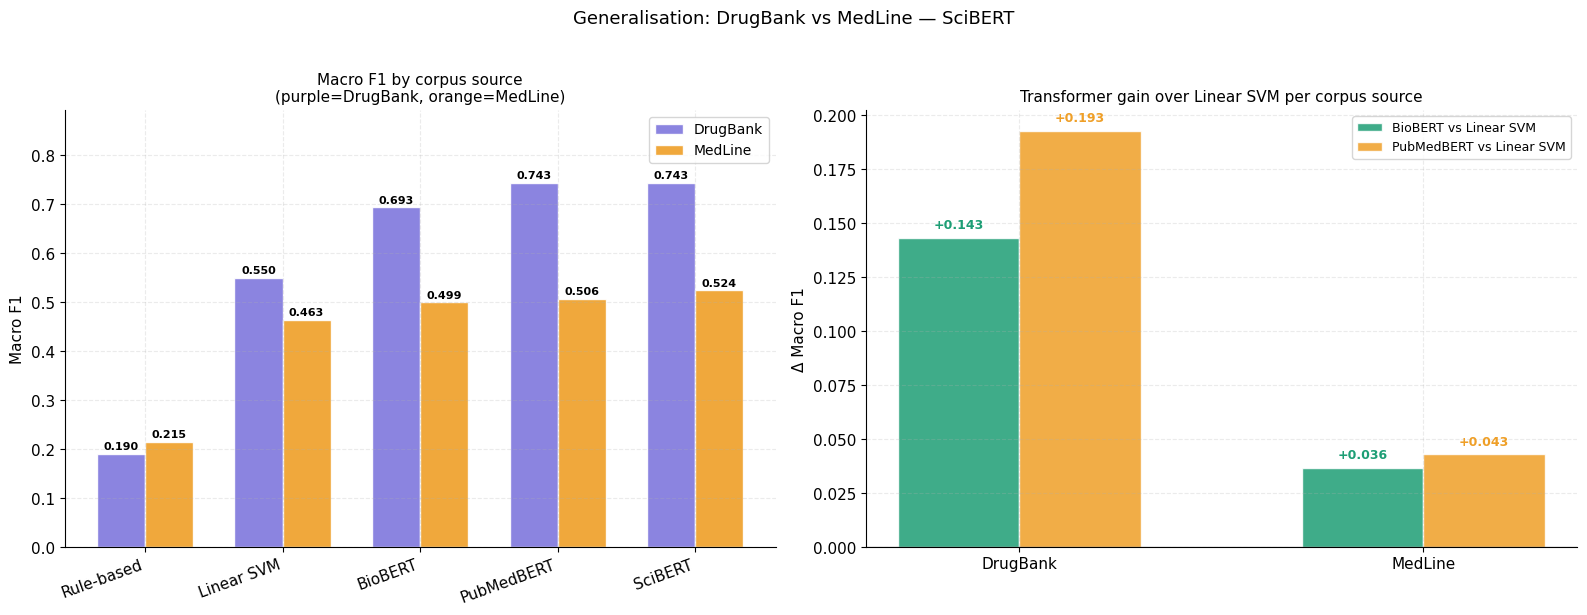

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

n_models = len(MODELS_FOR_ANALYSIS)
x = np.arange(n_models)
w = 0.35

db_f1s, ml_f1s = [], []

for m in MODELS_FOR_ANALYSIS:
    sub = source_df[source_df['Model'] == m]

    db_val = sub[sub['Source'] == 'DrugBank']['Macro F1'].values
    ml_val = sub[sub['Source'] == 'MedLine']['Macro F1'].values

    db_f1s.append(float(db_val[0]) if len(db_val) else 0)
    ml_f1s.append(float(ml_val[0]) if len(ml_val) else 0)

b1 = axes[0].bar(
    x - w/2,
    db_f1s,
    w,
    label='DrugBank',
    color='#7F77DD',
    edgecolor='white',
    alpha=0.9
)

b2 = axes[0].bar(
    x + w/2,
    ml_f1s,
    w,
    label='MedLine',
    color='#EF9F27',
    edgecolor='white',
    alpha=0.9
)

for bar, val in zip(list(b1) + list(b2), db_f1s + ml_f1s):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{val:.3f}',
        ha='center',
        va='bottom',
        fontsize=8,
        fontweight='bold'
    )

axes[0].set_xticks(x)
axes[0].set_xticklabels(MODELS_FOR_ANALYSIS, rotation=20, ha='right')
axes[0].set_title('Macro F1 by corpus source\n(purple=DrugBank, orange=MedLine)', fontsize=11)
axes[0].set_ylabel('Macro F1')
axes[0].legend(fontsize=10)
axes[0].set_ylim(0, max(db_f1s + ml_f1s) * 1.2)

# Delta plot
trans_in_analysis = [m for m in TRANS_AVAILABLE if m in MODELS_FOR_ANALYSIS]
clf_idx = MODELS_FOR_ANALYSIS.index(BEST_CLASSICAL) if BEST_CLASSICAL in MODELS_FOR_ANALYSIS else None

if len(trans_in_analysis) >= 1 and clf_idx is not None:
    x2 = np.arange(2)
    w2 = 0.3

    ref_db = db_f1s[clf_idx]
    ref_ml = ml_f1s[clf_idx]

    for k, trans in enumerate(trans_in_analysis[:2]):
        t_idx = MODELS_FOR_ANALYSIS.index(trans)

        delta_db = db_f1s[t_idx] - ref_db
        delta_ml = ml_f1s[t_idx] - ref_ml

        colour = MODEL_COLOURS.get(trans, '#888')
        offset = (k - len(trans_in_analysis[:2]) / 2 + 0.5) * w2

        bars_d = axes[1].bar(
            x2 + offset,
            [delta_db, delta_ml],
            w2,
            label=f'{trans} vs {BEST_CLASSICAL}',
            color=colour,
            edgecolor='white',
            alpha=0.85
        )

        for xi, val in enumerate([delta_db, delta_ml]):
            axes[1].text(
                xi + offset,
                val + 0.003,
                f'{val:+.3f}',
                ha='center',
                va='bottom',
                fontsize=9,
                fontweight='bold',
                color=colour
            )

    axes[1].axhline(0, color='black', linewidth=0.8)
    axes[1].set_xticks(x2)
    axes[1].set_xticklabels(['DrugBank', 'MedLine'])
    axes[1].set_title(f'Transformer gain over {BEST_CLASSICAL} per corpus source', fontsize=11)
    axes[1].set_ylabel('Δ Macro F1')
    axes[1].legend(fontsize=9)

else:
    axes[1].text(
        0.5, 0.5,
        'Insufficient data for delta plot',
        ha='center',
        va='center',
        transform=axes[1].transAxes
    )
    axes[1].axis('off')

plt.suptitle(
    f'Generalisation: DrugBank vs MedLine — {ATTN_MODEL_NAME}',
    fontsize=13,
    y=1.02
)

plt.tight_layout()
save_fig('generalisation_drugbank_vs_medline')

## Class-Specific Performance Analysis (INT Class Focus)

This section provides a detailed evaluation of model performance on the **`int` (interaction)** class, which typically represents more general or implicit interaction statements.

The analysis includes:
- **Class distribution** in the test set (int vs non-int)  
- **Accuracy within the int class** (how often the model correctly predicts `int`)  
- **Misclassification breakdown** (which classes `int` is confused with)  
- **Per-class F1 scores and support** for overall performance context  

This is particularly important because the `int` class is often:
- **Semantically broad and less explicit** than other classes  
- Prone to confusion with **mechanism**, **effect**, or **advise**  
- Sensitive to subtle linguistic cues  

Understanding performance on this class helps identify whether the model captures **generic interaction signals** or overfits to more specific patterns.

This analysis complements the earlier error categorisation by focusing on **class-level weaknesses rather than error types**.

In [15]:
int_test = test_df[test_df['true_label'] == 'int'].copy()
non_int_test = test_df[test_df['true_label'] != 'int'].copy()

print(f'int class test samples : {len(int_test):,}')
print(f'Non-int test samples : {len(non_int_test):,}')

print(f'\n{ATTN_MODEL_NAME} on int class:')

int_preds = test_df.loc[test_df['true_label'] == 'int', pred_col]

print(f'Correct : {(int_preds == "int").sum()} / {len(int_preds)} ({(int_preds == "int").mean()*100:.1f}%)')

print(' Predicted as:')
for cls, cnt in int_preds.value_counts().items():
    print(f'{cls:<12} {cnt:3d}  ({cnt/len(int_preds)*100:.1f}%)')

rep = classification_report(
    y_true,
    y_pred_best_trans,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

print(f'\n{ATTN_MODEL_NAME} F1 per class:')

for lbl in LABEL_ORDER:
    f1 = rep.get(lbl, {}).get('f1-score', 0)
    support = rep.get(lbl, {}).get('support', 0)

    print(f'{lbl:<12} F1={f1:.4f}  support={int(support)}')

int class test samples : 96
Non-int test samples : 6,561

SciBERT on int class:
Correct : 35 / 96 (36.5%)
 Predicted as:
effect        39  (40.6%)
int           35  (36.5%)
false         21  (21.9%)
mechanism      1  (1.0%)

SciBERT F1 per class:
false        F1=0.9571  support=5678
effect       F1=0.6930  support=360
mechanism    F1=0.7062  support=302
advise       F1=0.8008  support=221
int          F1=0.4965  support=96


## `int` Class Difficulty — Multi-Factor Analysis

This multi-panel analysis investigates why the **`int` (interaction)** class is typically the most challenging to model.

The figure combines six complementary perspectives:

### 1. Keyword Density  
Shows the average number of interaction-related keywords per class. Lower or less distinctive keyword presence in `int` suggests weaker lexical signals.

### 2. Sentence Length Distribution  
Compares sentence complexity across classes. Longer or more variable sentences can introduce ambiguity and dilute clear interaction cues.

### 3. Prediction Breakdown (Pie Chart)  
Illustrates how `int` samples are misclassified. Frequent confusion with *mechanism*, *effect*, or *advise* indicates semantic overlap.

### 4. F1 Score per Class  
Highlights overall model performance. A lower F1 score for `int` confirms it is harder to classify compared to other classes.

### 5. Negation Rate  
Shows how often negation appears in each class. Differences in negation patterns can affect model interpretation and lead to misclassification.

### 6. Class Support  
Displays the number of samples per class (log scale). Lower support for `int` can contribute to poorer generalisation.

### Key Insight

The `int` class is difficult because it:
- Lacks strong, distinctive keywords  
- Overlaps semantically with more specific interaction types  
- Often appears in more complex or ambiguous sentence structures  
- May have relatively limited training support  

This analysis provides a **multi-dimensional explanation** of model difficulty, combining linguistic, statistical, and performance-based evidence.

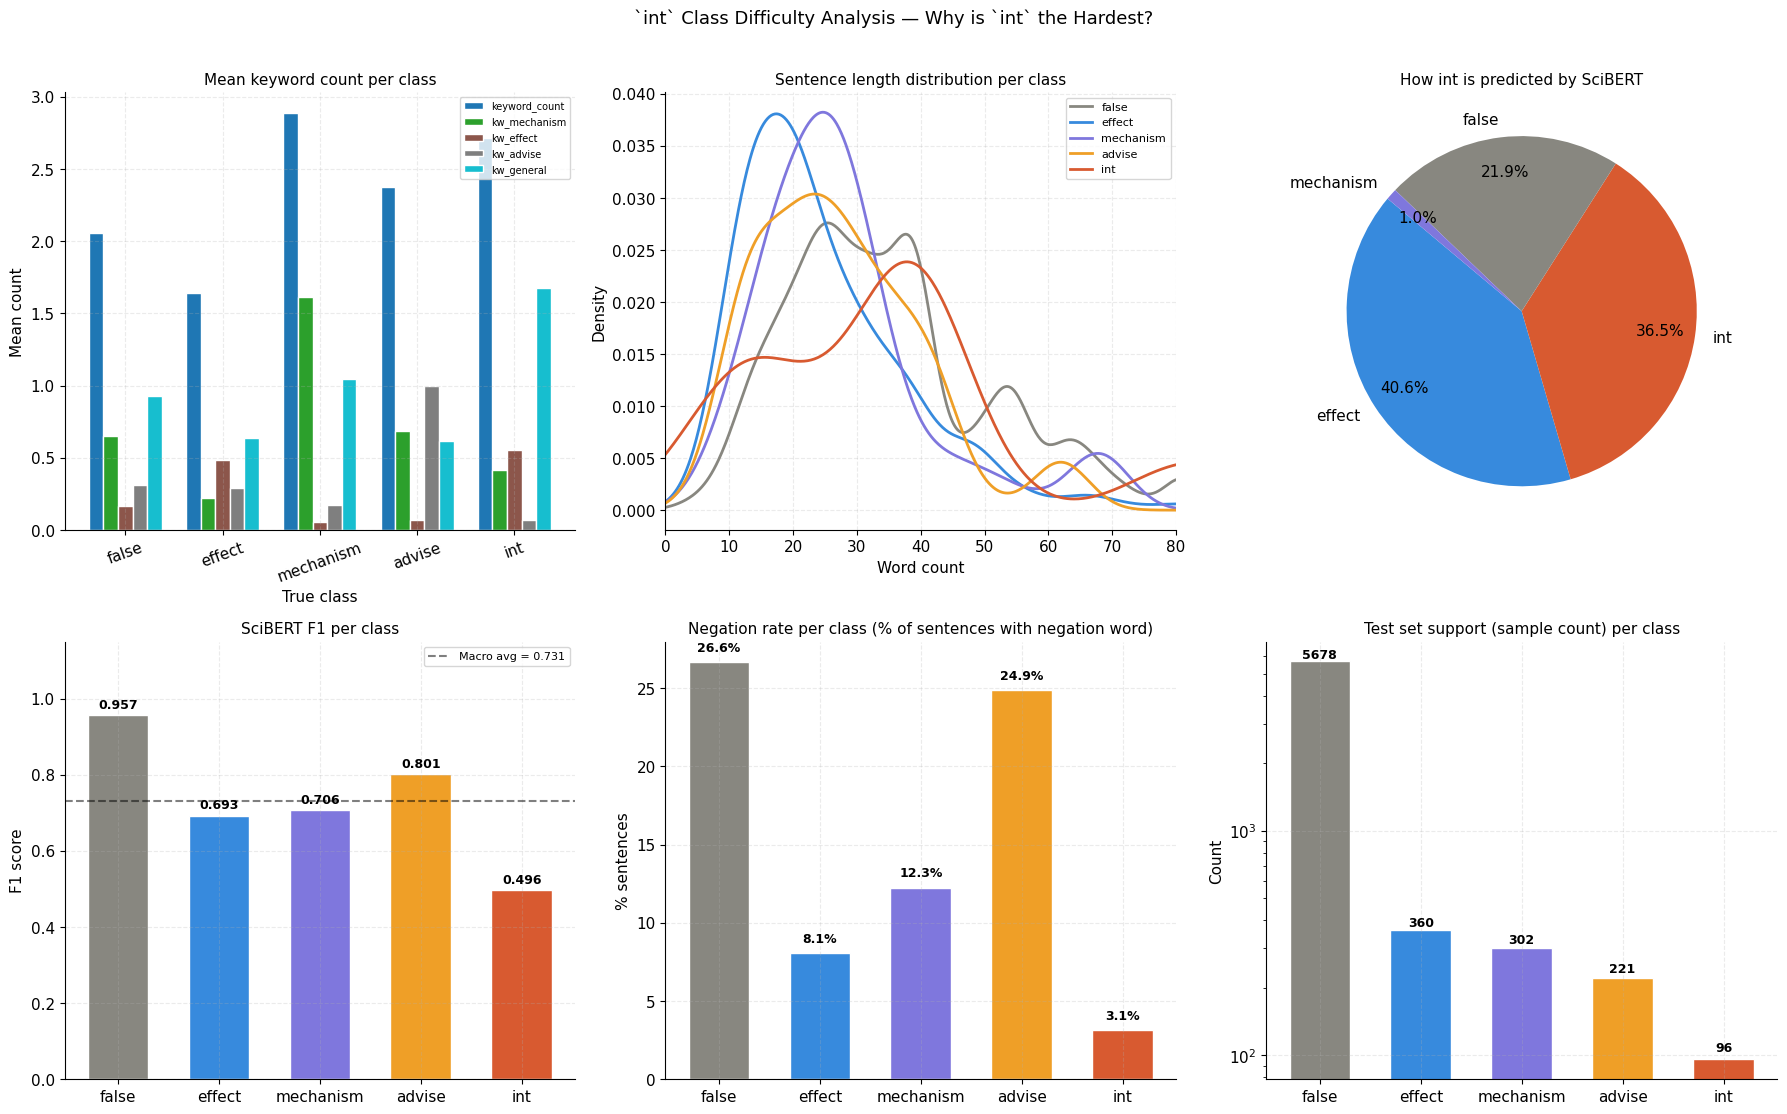

In [16]:
# Guard: derive any missing feature columns from available text columns
text_col = next(
    (c for c in ['sentence_cleaned','sentence_original','sentence_masked']
     if c in test_df.columns),
    None
)

text_series = (
    test_df[text_col].fillna('').astype(str).str.lower()
    if text_col else None
)

if 'sentence_length' not in test_df.columns and text_series is not None:
    test_df['sentence_length'] = text_series.str.split().str.len()

keyword_specs = {
    'kw_mechanism': ['inhibit','induce','metabolis','metaboliz','cyp','enzyme',
                     'clearance','absorption','bioavailability','excret','plasma','concentration','half-life','bind'],
    'kw_effect': ['bleeding','toxicity','adverse','sedation','hypotension',
                     'bradycardia','elevat','risk','prolong','danger','side'],
    'kw_advise': ['contraindicated','avoid','caution','monitor','warning','recommend','concomitant','concurrent'],
    'kw_general': ['interact','interaction','co-administration','combination','combined'],
}

for col, kws in keyword_specs.items():
    if col not in test_df.columns and text_series is not None:
        test_df[col] = text_series.apply(
            lambda s, kws=kws: sum(1 for kw in kws if kw in s)
        )

if 'keyword_count' not in test_df.columns:
    kw_cols = [c for c in keyword_specs if c in test_df.columns]
    test_df['keyword_count'] = (
        test_df[kw_cols].sum(axis=1) if kw_cols else 0
    )

if 'has_negation' not in test_df.columns and text_series is not None:
    neg_words = {'not','no','without','neither','nor','never','none'}
    test_df['has_negation'] = text_series.apply(
        lambda s: int(any(w in s.split() for w in neg_words))
    )

# --- 2×3 multi-panel analysis ---
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

fig.suptitle(
    '`int` Class Difficulty Analysis — Why is `int` the Hardest?',
    fontsize=13,
    y=1.01
)

kw_cols_present = [
    c for c in ['keyword_count','kw_mechanism','kw_effect','kw_advise','kw_general']
    if c in test_df.columns
]

# Panel 0,0: keyword density
ax = axes[0, 0]
kw_means = (
    test_df.groupby('true_label')[kw_cols_present]
    .mean()
    .reindex(LABEL_ORDER)
    .fillna(0)
)

kw_means.plot(
    kind='bar',
    ax=ax,
    legend=True,
    colormap='tab10',
    width=0.75,
    edgecolor='white'
)

ax.set_title('Mean keyword count per class', fontsize=11)
ax.set_xlabel('True class')
ax.set_ylabel('Mean count')
ax.tick_params(axis='x', rotation=20)
ax.legend(fontsize=7, loc='upper right')

# Panel 0,1: sentence length
ax = axes[0, 1]
if 'sentence_length' in test_df.columns:
    for lbl in LABEL_ORDER:
        sub = test_df[test_df['true_label'] == lbl]['sentence_length'].dropna()
        if len(sub):
            sub.plot.kde(ax=ax, label=lbl, color=LABEL_COLOURS[lbl], linewidth=2)

    ax.set_title('Sentence length distribution per class', fontsize=11)
    ax.set_xlabel('Word count')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.set_xlim(0, 80)
else:
    ax.text(0.5, 0.5, 'sentence_length column missing',
            ha='center', va='center', transform=ax.transAxes)
    ax.axis('off')

# Panel 0,2: int prediction pie
ax = axes[0, 2]
int_pred_counts = int_preds.value_counts()
colours_pie = [LABEL_COLOURS.get(c, '#888') for c in int_pred_counts.index]

ax.pie(
    int_pred_counts.values,
    labels=int_pred_counts.index,
    colors=colours_pie,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.8
)

ax.set_title(f'How int is predicted by {ATTN_MODEL_NAME}', fontsize=11)

# Panel 1,0: F1 per class
ax = axes[1, 0]
f1_per_class = [rep.get(lbl, {}).get('f1-score', 0) for lbl in LABEL_ORDER]

bars = ax.bar(
    LABEL_ORDER,
    f1_per_class,
    color=[LABEL_COLOURS[l] for l in LABEL_ORDER],
    edgecolor='white',
    width=0.6
)

for bar, val in zip(bars, f1_per_class):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{val:.3f}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

ax.axhline(
    np.mean(f1_per_class),
    color='black',
    linestyle='--',
    alpha=0.5,
    label=f'Macro avg = {np.mean(f1_per_class):.3f}'
)

ax.set_title(f'{ATTN_MODEL_NAME} F1 per class', fontsize=11)
ax.set_ylabel('F1 score')
ax.set_ylim(0, 1.15)
ax.legend(fontsize=8)

# Panel 1,1: negation rate
ax = axes[1, 1]
if 'has_negation' in test_df.columns:
    neg_rates = (
        test_df.groupby('true_label')['has_negation']
        .mean()
        .reindex(LABEL_ORDER) * 100
    )

    ax.bar(
        LABEL_ORDER,
        neg_rates.values,
        color=[LABEL_COLOURS[l] for l in LABEL_ORDER],
        edgecolor='white',
        width=0.6
    )

    for i, val in enumerate(neg_rates.values):
        ax.text(i, val + 0.5, f'{val:.1f}%',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_title('Negation rate per class (% of sentences with negation word)', fontsize=11)
    ax.set_ylabel('% sentences')
else:
    ax.text(0.5, 0.5, 'has_negation column missing',
            ha='center', va='center', transform=ax.transAxes)
    ax.axis('off')

# Panel 1,2: support
ax = axes[1, 2]
support_counts = [int(rep.get(lbl, {}).get('support', 0)) for lbl in LABEL_ORDER]

bars = ax.bar(
    LABEL_ORDER,
    support_counts,
    color=[LABEL_COLOURS[l] for l in LABEL_ORDER],
    edgecolor='white',
    width=0.6
)

for bar, val in zip(bars, support_counts):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5,
        str(val),
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

ax.set_title('Test set support (sample count) per class', fontsize=11)
ax.set_ylabel('Count')
ax.set_yscale('log')

plt.tight_layout()
save_fig('int_class_difficulty_analysis')

## Linguistic Examination of the `int` Class

This section performs a **qualitative linguistic analysis** of the `int` (interaction) class by inspecting individual test sentences.

The objective is to understand *why the model succeeds or fails* on this class by examining:
- **Correctly classified examples** → what signals the model captures  
- **Misclassified examples** → where the model breaks down  
- **Keyword patterns** → presence or absence of domain-specific cues  

### What this analysis reveals

#### 1. Weak lexical signals  
Unlike other classes, `int` relies on **generic interaction terms** (e.g., *interact*, *combination*), which lack specificity.

#### 2. High semantic overlap  
The language often overlaps with:
- **mechanism** (pharmacokinetics)
- **effect** (clinical outcomes)

This leads to systematic confusion.

#### 3. Residual class nature  
The `int` label is effectively a **fallback category**, used when:
- No clear mechanism is stated  
- No explicit effect is described  
- No actionable advice is given  

#### 4. Fuzzy decision boundaries  
Even for humans, distinguishing `int` from other classes is:
- Context-dependent  
- Subtle  
- Sometimes ambiguous  

#### 5. Data limitation  
Relatively low sample size reduces the model’s ability to:
- Learn strong representations  
- Generalise reliably  

### Key takeaway

The difficulty of the `int` class is **not just model weakness**, but a consequence of:
- **Linguistic ambiguity**
- **Annotation design**
- **Feature sparsity**

This makes it inherently harder than other classes in DDI classification.

In [17]:
print('-'*70)
print('`int` Class Test Sentences — Linguistic Examination')
print('-'*70)

int_rows = test_df[test_df['true_label'] == 'int'].copy()

print(f'\nTotal int test sentences : {len(int_rows)}')
print(f'{ATTN_MODEL_NAME} correct : {int_rows["model_correct"].sum()} ({int_rows["model_correct"].mean()*100:.1f}%)')
print()

print('--- Correctly classified `int` examples ---')

correct_int = int_rows[int_rows['model_correct'] == True]

for i, (_, row) in enumerate(correct_int.head(3).iterrows()):
    orig = str(row.get('sentence_original', row.get('sentence_masked','')))
    kw = str(row.get('keywords_found', ''))

    print(f'[{i+1}] {orig[:120]}')
    print(f'Keywords: {kw}  |  Pred: {row[pred_col]}')
    print()

print('--- Misclassified `int` examples ---')

wrong_int = int_rows[int_rows['model_correct'] == False]

for i, (_, row) in enumerate(wrong_int.head(5).iterrows()):
    orig = str(row.get('sentence_original', row.get('sentence_masked','')))
    kw = str(row.get('keywords_found', ''))

    print(f'[{i+1}] True: int  |  Pred: {row[pred_col]}')
    print(f'{orig[:120]}')
    print(f'Keywords: {kw}')
    print()

print('-'*70)
print(' INTERPRETATION')
print('-'*70)

print('1. `int` sentences rely on generic interaction language (e.g. "interact", "combination"),')
print('which lacks the specific pharmacological signals present in mechanism and effect classes.')
print()

print('2. Significant lexical overlap with mechanism and effect leads to systematic confusion.')
print()

print('3. The `int` class functions as an annotation residual category — assigned when no')
print('explicit mechanism, effect, or advice is identifiable.')
print()

print('4. This creates inherently fuzzy decision boundaries even for human annotators.')
print()

print('5. Data sparsity (96 test samples) further limits the model\'s ability to learn')
print('robust representations for this class.')

print('='*70)

----------------------------------------------------------------------
`int` Class Test Sentences — Linguistic Examination
----------------------------------------------------------------------

Total int test sentences : 96
SciBERT correct : 35 (36.5%)

--- Correctly classified `int` examples ---
[1] Some anticonvulsants may interact with Mephenytoin. 
Keywords: interact  |  Pred: int

[2] Mequitazine can interact with CNS depressant, antichlolinergic, TCA, MAOIs, and alcohol.
Keywords: interact  |  Pred: int

[3] Mequitazine can interact with CNS depressant, antichlolinergic, TCA, MAOIs, and alcohol.
Keywords: interact  |  Pred: int

--- Misclassified `int` examples ---
[1] True: int  |  Pred: false
Melatonin may interact with the following drugs: aspirin and other NSAIDs (may lower melatonin levels), fluvoxamine (bio
Keywords: inhibit, bioavailability, adverse, sedation, increase, decrease, lower, block, interact, level

[2] True: int  |  Pred: false
Melatonin may interact with the 

## Phase 8 Outputs — Saved Artefacts

This section lists all files generated during **(Analysis & Interpretability)**
This step finalises the analytical pipeline and prepares outputs for reporting.

In [18]:
print('Files saved:')
print()
for d, label in [(ANALYSIS_PLOTS_DIR, 'Plots'), (ANALYSIS_METRICS_DIR, 'Metrics')]:
    print(f'{label} ({d}):')
    for f in sorted(d.iterdir()):
        if f.is_file():
            print(f'  {f.name:<55}')
    print()


Files saved:

Plots (/Users/carinadesouza/Documents/Projects/Python/Drug Drug Interaction NLP project/results/plots/analysis):
  81b_domain_token_attention_pct.png                     
  82_error_categories.png                                
  83_generalisation_drugbank_vs_medline.png              
  84_int_class_difficulty_analysis.png                   
  domain_token_attention_pct.png                         
  error_categories.png                                   
  generalisation_drugbank_vs_medline.png                 
  int_class_difficulty_analysis.png                      

Metrics (/Users/carinadesouza/Documents/Projects/Python/Drug Drug Interaction NLP project/results/metrics/analysis):
  attention_top_tokens_per_class.csv                     
  domain_token_attention_pct.csv                         
  error_categories.csv                                   
  generalisation_by_source.csv                           



## Summary of Findings

The analysis reveals several key insights into model behaviour and limitations:

- **Attention patterns** indicate that transformer models generally focus on pharmacologically meaningful tokens, particularly for well-defined classes such as *mechanism* and *advise*.

- **Error categorisation** shows that most failures arise from:
  - Negation handling  
  - Long-range dependencies  
  - Semantic ambiguity between closely related classes  

- **Generalisation results** demonstrate that transformer models outperform classical and rule-based approaches, but performance varies across corpus sources, indicating sensitivity to domain differences.

- The **`int` class emerges as the most challenging**, due to:
  - Lack of distinctive lexical signals  
  - High semantic overlap with other classes  
  - Its role as a residual annotation category  
  - Limited training support  

- **Linguistic feature analysis** confirms that class separability is strongly influenced by keyword presence, sentence complexity, and negation patterns.

Overall, while transformer models achieve strong performance, the analysis highlights that **data characteristics and annotation design play a critical role** in determining model success. These findings suggest that future improvements should focus on better handling of ambiguity, richer feature representations, and more balanced data distributions.